# Aggregation 
- load events, filter for usable events (date range, >= 18 days)
- create event array for one of these events (first with +/- 2*365 days)
- average kNDVI time series per land cover type, write to df (LC + event number as unique identifier)
- apply STL decomposition on these TS per land cover type with optimized parameters from 3rd notebook

for steady state computatuon, i have to limit the selection of events to the ones that are not within 3 years (3*365) of the edges from the tempral coverage of kndvi data

also just test decomposition parameters on a couple of these TS (just to have something to show against overfitting)

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import xarray as xr

# Handling files
import requests
import zipfile
import tempfile
import io
import os
import glob

# Acces APIs
from xcube.core.store import new_data_store

# Plotting  
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Handling dates
import datetime
from datetime import timedelta

# Import own functions
from utils import event_sampling
from utils import event_visualization


## 1. Load data
- kNDVI
- event summary
- event cube
- land mask
- land cover

### 1.1 kNDVI array

In [2]:
# Import kNDVI dataset
# Load Earth System Data Cube store
store = new_data_store("s3", root="deep-esdl-public", storage_options=dict(anon=True))
ds_esdc = store.open_data('esdc-8d-0.25deg-1x720x1440-3.0.1.zarr')

# Select kNDVI
kndvi = ds_esdc['kndvi']

### 1.2 Event summary dataframe

In [3]:
# URL
url_chd_summary = "https://zenodo.org/records/14884254/files/MergedEventStats_landonly_int.csv.zip?download=1"

# Download the ZIP file
response = requests.get(url_chd_summary)
response.raise_for_status()

# Unzip the content
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    csv_filename = z.namelist()[0]
    with z.open(csv_filename) as f:
        df_chd_summary = pd.read_csv(f)

# Create new column 'duration_days' with numeric values
df_chd_summary['duration_days'] = df_chd_summary['duration'].str.extract(r'(\d+)').astype(int)

# Convert start_time and end_time to datetime
df_chd_summary['start_time'] = pd.to_datetime(df_chd_summary['start_time'])
df_chd_summary['end_time'] = pd.to_datetime(df_chd_summary['end_time'])

# Filter dataframe for event duration
df_chd_filtered = df_chd_summary[df_chd_summary['duration_days'] >= 18]

# Filter dataframe for period of ESDC kndvi data
df_chd_filtered = df_chd_filtered[
    (df_chd_filtered['start_time'].dt.year >= 2002) &
    (df_chd_filtered['start_time'].dt.year <= 2019) &
    (df_chd_filtered['end_time'].dt.year >= 2002) &
    (df_chd_filtered['end_time'].dt.year <= 2019)
]

print(len(df_chd_filtered))

# Show DataFrame 
df_chd_filtered.sort_values('duration_days', ascending=False).head(10)


189


,label,start_time,end_time,longitude_min,longitude_max,latitude_min,latitude_max,t2mmax_mean,t2mmax_min,t2mmax_max,...,compound,land_share,inth,intd30,intd90,intd180,volume,duration,area,duration_days
10,105411,2016-02-27,2016-05-20,92.75,118.25,3.00,23.50,38.429633,29.907460,45.535502,...,100.0,100.0,16248.457214,10882.885354,11231.448425,4240.130612,22975.648359,84 days,273.519623,84
2247,100731,2015-07-14,2015-09-16,286.00,287.50,18.25,18.50,32.880938,29.240437,36.768260,...,100.0,100.0,218.550028,139.169701,181.245710,62.101517,304.527434,65 days,4.685037,65
178,104887,2016-02-09,2016-04-11,281.50,289.25,6.75,11.00,36.907783,22.837075,43.576030,...,100.0,100.0,2804.125332,957.145596,2107.004000,68.015374,3891.942409,63 days,61.776864,63
5813,109935,2017-01-27,2017-03-28,281.50,284.25,-14.75,-9.00,30.171803,27.822229,32.105410,...,100.0,100.0,63.215312,45.751063,38.967732,31.212608,85.665001,61 days,1.404344,61
21,86754,2011-07-15,2011-09-06,257.50,268.50,25.25,38.75,39.917825,29.952395,44.899790,...,100.0,100.0,10715.279400,7707.308031,7458.921376,5892.946581,17479.844032,54 days,323.700815,54
2383,97552,2014-08-15,2014-10-07,237.50,248.25,24.75,38.00,33.195644,27.402290,41.851355,...,100.0,100.0,173.154032,13.869059,76.569025,222.459604,279.819932,54 days,5.181851,54
6754,107867,2016-07-22,2016-09-13,321.75,340.75,65.75,77.50,11.604721,5.434857,19.997050,...,100.0,100.0,41.709392,40.295264,6.090612,0.285918,68.632860,54 days,1.270979,54
3,104409,2016-01-20,2016-03-13,0.00,359.75,-0.25,11.00,37.855397,25.982071,44.140147,...,100.0,100.0,24790.693774,19095.290823,18766.811721,306.037278,38512.666189,54 days,713.197522,54
2,83007,2010-07-02,2010-08-21,4.50,64.50,36.00,65.50,35.294501,21.937143,46.318790,...,100.0,100.0,66906.175092,68960.197766,36294.144024,11858.191820,87107.659248,51 days,1707.993319,51
39,107547,2016-07-02,2016-08-21,55.75,98.00,62.25,74.50,27.641322,12.107263,33.150924,...,100.0,100.0,7851.432595,9672.583045,3667.564724,509.444570,11650.042910,51 days,228.432214,51


### 1.3 Event cube dataset

In [4]:
# Open zarr dataset
ds_chd_labels = xr.open_zarr('data/temp_zarr_extracted/mergedlabels_ranked_pot0.01_ne0.1_cmp_S1_T3_1950_2023.zarr', consolidated=False)

### 1.4 Land mask array and class rtanslation dataframe

In [5]:
# Open with xarray
path_landmask = "data/GLDASp5_landmask_025d.nc4"
ds_landmask = xr.open_dataset(path_landmask)

# Open the right variable as land mask
landmask = ds_landmask['GLDAS_mask']

In [6]:
# Open class translation dataframe
df_translation = pd.read_csv("data/GLDA_veg_legend.csv", index_col=0)

### 1.5 Land cover array
Either use [Land Cover Cube (0.027 degrees)](https://deepesdl.readthedocs.io/en/latest/datasets/LC-1x2025x2025-2-0-0-levels/) or [GLDAS DOminant Vegetation (VIC, 1 degree)](https://ldas.gsfc.nasa.gov/gldas/vegetation-class-mask).

In [7]:
# Open with xarray
path_veg = 'data/GLDASp5_domveg_NOAH3.6_025d.nc4'
ds_veg = xr.open_dataset(path_veg)

# Open the right variable
vegetation = ds_veg['GLDAS_domveg']

## 2. Prepare data

- create event mask with land mask and label cube
- create event array with kndvi data array and event mask

### 2.1 Event mask


In [8]:
# Create event area mask 
event_mask_105411 = event_sampling.create_event_mask(105411, event_table=df_chd_filtered, labelcube=ds_chd_labels, land_mask=landmask)

### 2.2 Event array

In [9]:
# 2 years buffer
buffer = 2 * 365

# Create event array
kndvi_array_105411 = event_sampling.create_event_dataarray(kndvi, event_mask_105411, df_chd_filtered, 105411, time_buffer=buffer)

## 3. Aggregate data per land cover type

try first most basic form: one kndvi mean per lc class

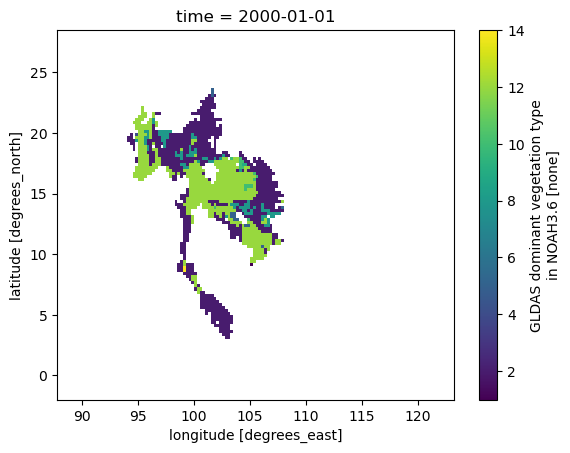

In [19]:
# Interpolate vegetation to match kndvi_array_105411's lat/lon grid
vegetation_interp = vegetation.interp_like(kndvi_array_105411.isel(time=0), method="nearest")

# Interpolate event mask to same grid (if needed)
event_mask_interp = event_mask_105411.interp_like(kndvi_array_105411.isel(time=0), method="nearest")

# Apply the event mask
vegetation_masked = vegetation_interp.where(event_mask_interp)

# Plot the result
vegetation_masked.plot()


In [20]:
# Remove time dimension of vegetation_masked
vegetation_2d = vegetation_masked.isel(time=0)  

# Add vegetation masked as dimension to kndvi_array_105411
kndvi_array_105411 = kndvi_array_105411.assign_coords(vegetation_type=(('lat', 'lon'), vegetation_2d.values))

In [ ]:
# Step 1: Drop 'time' dimension from vegetation_masked if it exists
if 'time' in vegetation_masked.dims:
    vegetation_masked = vegetation_masked.isel(time=0)

# Step 2: Stack spatial dimensions into one
veg_stacked = vegetation_masked.stack(space=('lat', 'lon'))  # (space,)
kndvi_stacked = kndvi_array_105411.stack(space=('lat', 'lon'))  # (time, space)

# Step 3: Compute valid mask (non-NaN for both arrays)
# Need to check for all NaNs across time in kndvi
valid_mask = (~np.isnan(veg_stacked)) & (~np.isnan(kndvi_stacked).all(dim='time'))

# Compute mask if dask-backed
if hasattr(valid_mask, 'compute'):
    valid_mask = valid_mask.compute()

# Step 4: Apply mask
veg_valid = veg_stacked.where(valid_mask, drop=True)                     # (space_valid,)
kndvi_valid = kndvi_stacked.isel(space=valid_mask.values)               # (time, space_valid)

# Step 5: Convert to pandas DataFrame
kndvi_df = pd.DataFrame(
    kndvi_valid.transpose('space', 'time').values,  # shape (space_valid, time)
    columns=kndvi_valid['time'].values
)
kndvi_df['veg_class'] = veg_valid.values  # shape (space_valid,)

# Step 6: Group by vegetation class, average across space
df_grouped = kndvi_df.groupby('veg_class').mean().T  # (time, veg_class)

# Step 7: (Optional) Convert index to datetime
df_grouped.index = pd.to_datetime(df_grouped.index)

# Result: df_grouped = one mean kNDVI time series per vegetation type


#### Visualisation of the results

In [32]:
# Create mapping of class labels to class names
translation_dict = dict(zip(df_translation.index, df_translation.iloc[:, 0]))

# Rename df_grouped columns (excluding time index if it's part of the DataFrame)
df_grouped = df_grouped.rename(columns=translation_dict)

# Determine event start and end
start_time_value = df_chd_filtered.loc[df_chd_filtered['label'] == 105411, 'start_time'].values[0]
end_time_value = df_chd_filtered.loc[df_chd_filtered['label'] == 105411, 'end_time'].values[0]

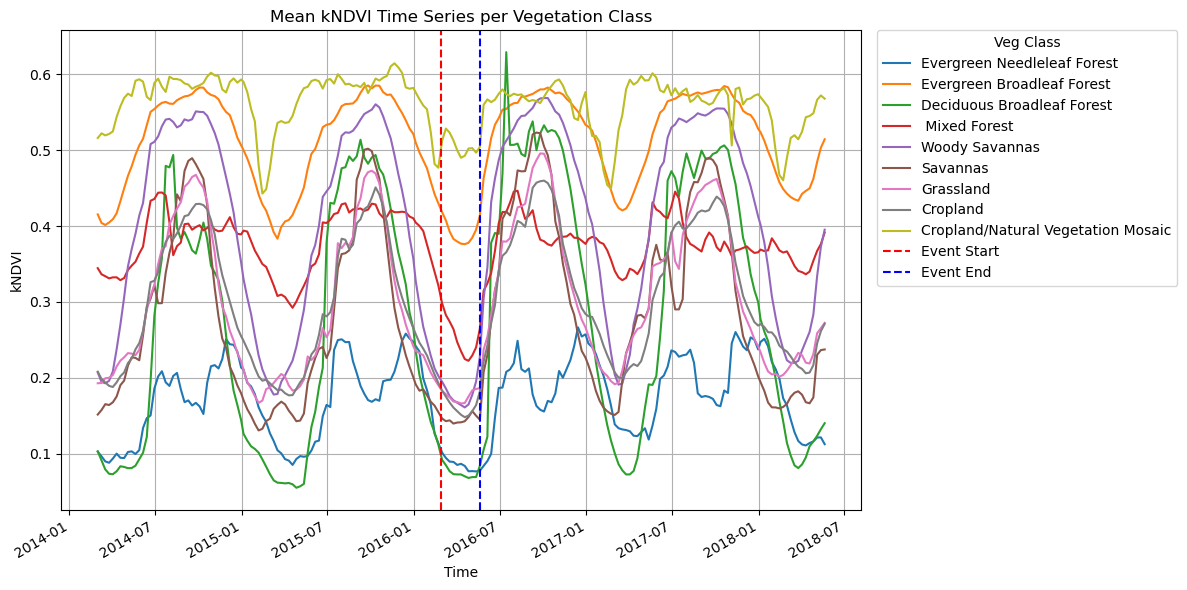

In [34]:
df_grouped.plot(figsize=(12, 6))
plt.axvline(start_time_value, color='red', linestyle='--', label='Event Start')
plt.axvline(end_time_value, color='blue', linestyle='--', label='Event End')
plt.title("Mean kNDVI Time Series per Vegetation Class")
plt.xlabel("Time")
plt.ylabel("kNDVI")
# Legend outside (right side)
plt.legend(
    title="Veg Class",
    bbox_to_anchor=(1.02, 1),  # shift right outside
    loc='upper left',
    borderaxespad=0
)
plt.grid(True)
plt.tight_layout()
plt.show()


In [28]:
df_translation

,missing value
0,
1,Evergreen Needleleaf Forest
2,Evergreen Broadleaf Forest
3,Deciduous Needleleaf Forest
4,Deciduous Broadleaf Forest
5,Mixed Forest
6,Closed Shrublands
7,Open Shrublands
8,Woody Savannas
9,Savannas


In [29]:
df_grouped

veg_class,1.0,2.0,4.0,5.0,8.0,9.0,10.0,12.0,14.0
2014-03-02,0.102487,0.415434,0.102925,0.344499,0.207056,0.151443,0.192727,0.207949,0.516166
2014-03-02,0.102487,0.415434,0.102925,0.344499,0.207056,0.151443,0.192727,0.207949,0.516166
2014-03-02,0.102487,0.415434,0.102925,0.344499,0.207056,0.151443,0.192727,0.207949,0.516166
2014-03-02,0.102487,0.415434,0.102925,0.344499,0.207056,0.151443,0.192727,0.207949,0.516166
2014-03-02,0.102487,0.415434,0.102925,0.344499,0.207056,0.151443,0.192727,0.207949,0.516166
...,...,...,...,...,...,...,...,...,...
2018-05-13,0.121303,0.503497,0.132132,0.376374,0.372846,0.236497,0.265430,0.261492,0.572320
2018-05-21,0.112425,0.514470,0.139989,0.391550,0.395262,0.237304,0.272402,0.271053,0.568066
2018-05-21,0.112425,0.514470,0.139989,0.391550,0.395262,0.237304,0.272402,0.271053,0.568066
2018-05-21,0.112425,0.514470,0.139989,0.391550,0.395262,0.237304,0.272402,0.271053,0.568066
